# CS 5326 PA1 — Complete Jupyter Notebook
## The Modern Transformer LM

This notebook is designed to be run from the **assignment repository**. It writes the implementation into `src/pa1.py`, connects `tests/adapters.py`, runs the public tests, loads TinyStories, supports debugging/tuning, performs the required 10,000-update training run, standardized evaluation, text generation, plotting, `final_model.pt` export, and submission packaging.

**Important:** expensive training cells are disabled by default. Do not simply click **Run All** and expect the 10,000-step run to start. Enable the explicit flags when you reach those sections.

The notebook follows the assignment restrictions: no `nn.Linear`, `nn.Embedding`, built-in `AdamW`, built-in cross-entropy, built-in attention, built-in gradient clipping, or other prohibited high-level implementations inside `src/`.


## Cell 1 — Find the repository and select the device

Place this notebook anywhere inside the `cs5326-pa1` repository, or set `REPO_ROOT` manually below.

For the notebook kernel, use the repository's Python environment if possible. On Windows this is usually `.venv\Scripts\python.exe`; on macOS/Linux it is `.venv/bin/python`.


In [1]:
from pathlib import Path
import os
import sys
import shutil
import subprocess
import math
import json
import csv

REPO_ROOT = Path(r"D:\1 - Personal\Docs\Noor\Gen AI PA1\cs5326-pa1")

def find_repo(start: Path) -> Path:
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "tests" / "adapters.py").exists() and (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError(
        "Could not find the PA1 repository. Set REPO_ROOT manually to the cs5326-pa1 folder."
    )

ROOT = Path(REPO_ROOT).expanduser().resolve() if REPO_ROOT else find_repo(Path.cwd().resolve())
os.chdir(ROOT)
print("Repository:", ROOT)
print("Python:", sys.executable)
print("uv:", shutil.which("uv"))

import numpy as np
import torch
import matplotlib.pyplot as plt
from tokenizers import Tokenizer

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
if DEVICE.type == "cpu":
    print("WARNING: the full 10,000-step training run will be very slow on CPU.")

(ROOT / "src").mkdir(exist_ok=True)
(ROOT / "experiments").mkdir(exist_ok=True)
(ROOT / "report_assets").mkdir(exist_ok=True)

Repository: D:\1 - Personal\Docs\Noor\Gen AI PA1\cs5326-pa1
Python: c:\Python310\python.exe
uv: C:\Python310\Scripts\uv.EXE
PyTorch: 2.6.0+cu124
Device: cuda


## Cell 2 — Write the complete assignment implementation

This cell creates `src/pa1.py`. It contains:

- custom bias-free `Linear`
- custom `Embedding`
- `RMSNorm`
- SiLU and SwiGLU
- adjacent-pair RoPE
- stable softmax
- scaled dot-product attention
- causal grouped-query self-attention
- Transformer block and complete Transformer LM
- cross-entropy
- custom AdamW
- warmup + cosine schedule
- global gradient clipping
- memory-mapped dataset loader
- next-token batch sampler
- checkpoint save/load
- validation
- temperature + top-p generation
- training loop
- final model export


In [2]:
%%writefile src/pa1.py
from __future__ import annotations

import csv
import math
import os
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import BinaryIO, Iterable

import numpy as np
import torch
from torch import Tensor
from torch import nn
from torch.optim import Optimizer


class Linear(nn.Module):
    def __init__(
        self,
        in_features: int,
        out_features: int,
        device: torch.device | str | None = None,
        dtype: torch.dtype | None = None,
    ) -> None:
        super().__init__()
        if not isinstance(in_features, int) or isinstance(in_features, bool) or in_features <= 0:
            raise ValueError("in_features must be a positive integer")
        if not isinstance(out_features, int) or isinstance(out_features, bool) or out_features <= 0:
            raise ValueError("out_features must be a positive integer")
        self.in_features = in_features
        self.out_features = out_features
        self.weight = nn.Parameter(torch.empty(out_features, in_features, device=device, dtype=dtype))
        std = math.sqrt(2.0 / (in_features + out_features))
        nn.init.trunc_normal_(self.weight, mean=0.0, std=std, a=-3.0 * std, b=3.0 * std)

    def forward(self, x: Tensor) -> Tensor:
        if x.shape[-1] != self.in_features:
            raise ValueError(f"expected final dimension {self.in_features}, got {x.shape[-1]}")
        return x @ self.weight.transpose(-1, -2)


class Embedding(nn.Module):
    def __init__(
        self,
        num_embeddings: int,
        embedding_dim: int,
        device: torch.device | str | None = None,
        dtype: torch.dtype | None = None,
    ) -> None:
        super().__init__()
        if not isinstance(num_embeddings, int) or isinstance(num_embeddings, bool) or num_embeddings <= 0:
            raise ValueError("num_embeddings must be a positive integer")
        if not isinstance(embedding_dim, int) or isinstance(embedding_dim, bool) or embedding_dim <= 0:
            raise ValueError("embedding_dim must be a positive integer")
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.weight = nn.Parameter(torch.empty(num_embeddings, embedding_dim, device=device, dtype=dtype))
        nn.init.trunc_normal_(self.weight, mean=0.0, std=1.0, a=-3.0, b=3.0)

    def forward(self, token_ids: Tensor) -> Tensor:
        if token_ids.dtype not in _INTEGER_DTYPES:
            raise TypeError("token_ids must have an integer dtype")
        return self.weight[token_ids.long()]


class RMSNorm(nn.Module):
    def __init__(
        self,
        d_model: int,
        norm_eps: float = 1e-5,
        device: torch.device | str | None = None,
        dtype: torch.dtype | None = None,
    ) -> None:
        super().__init__()
        if not isinstance(d_model, int) or isinstance(d_model, bool) or d_model <= 0:
            raise ValueError("d_model must be a positive integer")
        if norm_eps < 0:
            raise ValueError("norm_eps must be nonnegative")
        self.d_model = d_model
        self.norm_eps = float(norm_eps)
        self.weight = nn.Parameter(torch.ones(d_model, device=device, dtype=dtype))

    def forward(self, x: Tensor) -> Tensor:
        if not x.is_floating_point():
            raise TypeError("RMSNorm input must be floating point")
        if x.shape[-1] != self.d_model:
            raise ValueError(f"expected final dimension {self.d_model}, got {x.shape[-1]}")
        in_dtype = x.dtype
        if in_dtype in (torch.float16, torch.bfloat16):
            work = x.to(torch.float32)
            gain = self.weight.to(torch.float32)
        else:
            work = x
            gain = self.weight.to(work.dtype)
        inv_rms = torch.rsqrt(work.square().mean(dim=-1, keepdim=True) + self.norm_eps)
        return (work * inv_rms * gain).to(in_dtype)


def silu(x: Tensor) -> Tensor:
    return x * torch.sigmoid(x)


class SwiGLU(nn.Module):
    def __init__(
        self,
        d_model: int,
        d_ff: int,
        device: torch.device | str | None = None,
        dtype: torch.dtype | None = None,
    ) -> None:
        super().__init__()
        self.gate = Linear(d_model, d_ff, device=device, dtype=dtype)
        self.up = Linear(d_model, d_ff, device=device, dtype=dtype)
        self.down = Linear(d_ff, d_model, device=device, dtype=dtype)

    def forward(self, x: Tensor) -> Tensor:
        return self.down(silu(self.gate(x)) * self.up(x))


_INTEGER_DTYPES = {
    torch.uint8,
    torch.int8,
    torch.int16,
    torch.int32,
    torch.int64,
}
if hasattr(torch, "uint16"):
    _INTEGER_DTYPES.add(torch.uint16)
if hasattr(torch, "uint32"):
    _INTEGER_DTYPES.add(torch.uint32)
if hasattr(torch, "uint64"):
    _INTEGER_DTYPES.add(torch.uint64)


class RotaryPositionalEmbedding(nn.Module):
    def __init__(
        self,
        rope_theta: float,
        head_dim: int,
        context_length: int,
        device: torch.device | str | None = None,
    ) -> None:
        super().__init__()
        if not isinstance(head_dim, int) or isinstance(head_dim, bool) or head_dim <= 0:
            raise ValueError("head_dim must be a positive integer")
        if head_dim % 2 != 0:
            raise ValueError("head_dim must be even for adjacent-pair RoPE")
        if not isinstance(context_length, int) or isinstance(context_length, bool) or context_length <= 0:
            raise ValueError("context_length must be a positive integer")
        if not isinstance(rope_theta, (int, float)) or rope_theta <= 0:
            raise ValueError("rope_theta must be positive")
        self.rope_theta = float(rope_theta)
        self.head_dim = head_dim
        self.context_length = context_length

        pair_coordinates = torch.arange(0, head_dim, 2, dtype=torch.float32, device=device)
        inv_freq = self.rope_theta ** (-pair_coordinates / head_dim)
        positions = torch.arange(context_length, dtype=torch.float32, device=device)
        angles = positions[:, None] * inv_freq[None, :]
        self.register_buffer("cos_cache", angles.cos(), persistent=False)
        self.register_buffer("sin_cache", angles.sin(), persistent=False)

    def forward(self, x: Tensor, token_positions: Tensor) -> Tensor:
        if x.ndim < 2:
            raise ValueError("RoPE input must have sequence and head_dim dimensions")
        if not x.is_floating_point():
            raise TypeError("RoPE input must be floating point")
        if x.shape[-1] != self.head_dim:
            raise ValueError(f"input head_dim is {x.shape[-1]}, expected head_dim={self.head_dim}")
        if token_positions.ndim < 1:
            raise ValueError("token_positions must have a sequence dimension")
        if token_positions.dtype not in _INTEGER_DTYPES:
            raise TypeError("token_positions must have an integer dtype")
        sequence_length = x.shape[-2]
        if token_positions.shape[-1] != sequence_length:
            raise ValueError("token_positions final dimension must match sequence length")

        x_batch_dims = x.ndim - 2
        pos_batch_dims = token_positions.ndim - 1
        if pos_batch_dims > x_batch_dims:
            raise ValueError("token_positions has too many leading dimensions")
        for pos_size, x_size in zip(token_positions.shape[:-1], x.shape[:pos_batch_dims]):
            if pos_size not in (1, x_size) and x_size != 1:
                raise ValueError("token_positions leading dimensions are not broadcastable")

        if token_positions.numel() > 0:
            pos_min = int(token_positions.min().item())
            pos_max = int(token_positions.max().item())
            if pos_min < 0 or pos_max >= self.context_length:
                raise ValueError(f"token_positions contains a position outside [0, {self.context_length})")

        indices = token_positions.to(device=self.cos_cache.device, dtype=torch.long)
        cos = self.cos_cache[indices]
        sin = self.sin_cache[indices]
        extra_singletons = (1,) * (x_batch_dims - pos_batch_dims)
        cache_shape = (*token_positions.shape[:-1], *extra_singletons, sequence_length, self.head_dim // 2)
        cos = cos.reshape(cache_shape)
        sin = sin.reshape(cache_shape)

        even = x[..., 0::2]
        odd = x[..., 1::2]
        out_even = even * cos - odd * sin
        out_odd = even * sin + odd * cos
        return torch.stack((out_even, out_odd), dim=-1).flatten(-2).to(x.dtype)


def softmax(x: Tensor, dim: int) -> Tensor:
    maximum = x.max(dim=dim, keepdim=True).values
    exp_shifted = torch.exp(x - maximum)
    return exp_shifted / exp_shifted.sum(dim=dim, keepdim=True)


def scaled_dot_product_attention(
    queries: Tensor,
    keys: Tensor,
    values: Tensor,
    mask: Tensor | None = None,
) -> Tensor:
    if queries.ndim < 2 or keys.ndim < 2 or values.ndim < 2:
        raise ValueError("queries, keys, and values must each have at least two dimensions")
    if queries.shape[-1] != keys.shape[-1]:
        raise ValueError("query and key feature dimensions must match")
    if keys.shape[-2] != values.shape[-2]:
        raise ValueError("key and value sequence lengths must match")
    if queries.shape[-1] <= 0 or keys.shape[-2] <= 0:
        raise ValueError("attention feature and key sequence dimensions must be nonempty")

    scores = torch.matmul(queries, keys.transpose(-2, -1)) / math.sqrt(queries.shape[-1])
    if mask is not None:
        if mask.dtype != torch.bool:
            raise TypeError("attention mask must be boolean")
        if mask.ndim < 2 or mask.shape[-2:] != scores.shape[-2:]:
            raise ValueError("attention mask final dimensions must match query/key sequence dimensions")
        try:
            broadcast_shape = torch.broadcast_shapes(scores.shape, mask.shape)
        except RuntimeError as exc:
            raise ValueError("attention mask is not broadcastable to attention scores") from exc
        if tuple(broadcast_shape) != tuple(scores.shape):
            raise ValueError("attention mask may not expand the attention score batch dimensions")
        expanded_mask = torch.broadcast_to(mask, scores.shape)
        if (~expanded_mask).all(dim=-1).any().item():
            raise ValueError("attention mask leaves a query with no permitted key positions")
        scores = scores.masked_fill(~expanded_mask, -torch.inf)

    probabilities = softmax(scores, dim=-1)
    try:
        return torch.matmul(probabilities, values)
    except RuntimeError as exc:
        raise ValueError("attention leading dimensions are not broadcastable") from exc


class GroupedQuerySelfAttention(nn.Module):
    def __init__(
        self,
        d_model: int,
        n_q_heads: int,
        n_kv_heads: int,
        context_length: int,
        rope_theta: float,
        device: torch.device | str | None = None,
        dtype: torch.dtype | None = None,
    ) -> None:
        super().__init__()
        for name, value in (("d_model", d_model), ("n_q_heads", n_q_heads), ("n_kv_heads", n_kv_heads)):
            if not isinstance(value, int) or isinstance(value, bool) or value <= 0:
                raise ValueError(f"{name} must be a positive integer")
        if d_model % n_q_heads != 0:
            raise ValueError("d_model must be divisible by n_q_heads")
        if n_q_heads % n_kv_heads != 0:
            raise ValueError("n_q_heads must be divisible by n_kv_heads")
        self.d_model = d_model
        self.n_q_heads = n_q_heads
        self.n_kv_heads = n_kv_heads
        self.context_length = context_length
        self.head_dim = d_model // n_q_heads
        self.group_size = n_q_heads // n_kv_heads

        self.q_proj = Linear(d_model, n_q_heads * self.head_dim, device=device, dtype=dtype)
        self.k_proj = Linear(d_model, n_kv_heads * self.head_dim, device=device, dtype=dtype)
        self.v_proj = Linear(d_model, n_kv_heads * self.head_dim, device=device, dtype=dtype)
        self.out_proj = Linear(n_q_heads * self.head_dim, d_model, device=device, dtype=dtype)
        self.rope = RotaryPositionalEmbedding(rope_theta, self.head_dim, context_length, device=device)

    def forward(self, x: Tensor, token_positions: Tensor | None = None) -> Tensor:
        if x.ndim != 3 or x.shape[-1] != self.d_model:
            raise ValueError("attention input must have shape [batch, sequence, d_model]")
        batch_size, sequence_length, _ = x.shape
        if sequence_length < 1 or sequence_length > self.context_length:
            raise ValueError("attention sequence length is outside the supported context window")
        if token_positions is None:
            token_positions = torch.arange(sequence_length, device=x.device, dtype=torch.long)

        q = self.q_proj(x).reshape(
            batch_size, sequence_length, self.n_kv_heads, self.group_size, self.head_dim
        ).permute(0, 2, 3, 1, 4)
        k = self.k_proj(x).reshape(
            batch_size, sequence_length, self.n_kv_heads, self.head_dim
        ).permute(0, 2, 1, 3)
        v = self.v_proj(x).reshape(
            batch_size, sequence_length, self.n_kv_heads, self.head_dim
        ).permute(0, 2, 1, 3)

        q = self.rope(q, token_positions)
        k = self.rope(k, token_positions)
        causal = torch.ones(sequence_length, sequence_length, dtype=torch.bool, device=x.device).tril()
        attended = scaled_dot_product_attention(q, k.unsqueeze(2), v.unsqueeze(2), causal)
        merged = attended.permute(0, 3, 1, 2, 4).reshape(batch_size, sequence_length, self.d_model)
        return self.out_proj(merged)


class TransformerBlock(nn.Module):
    def __init__(
        self,
        d_model: int,
        n_q_heads: int,
        n_kv_heads: int,
        d_ff: int,
        context_length: int,
        rope_theta: float,
        norm_eps: float = 1e-5,
        device: torch.device | str | None = None,
        dtype: torch.dtype | None = None,
    ) -> None:
        super().__init__()
        self.attention = GroupedQuerySelfAttention(
            d_model, n_q_heads, n_kv_heads, context_length, rope_theta, device=device, dtype=dtype
        )
        self.attention_norm = RMSNorm(d_model, norm_eps, device=device, dtype=dtype)
        self.ffn_norm = RMSNorm(d_model, norm_eps, device=device, dtype=dtype)
        self.ffn = SwiGLU(d_model, d_ff, device=device, dtype=dtype)

    def forward(self, x: Tensor, token_positions: Tensor | None = None) -> Tensor:
        x = x + self.attention(self.attention_norm(x), token_positions=token_positions)
        x = x + self.ffn(self.ffn_norm(x))
        return x


class TransformerLM(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        context_length: int,
        d_model: int,
        num_layers: int,
        n_q_heads: int,
        n_kv_heads: int,
        d_ff: int,
        rope_theta: float,
        norm_eps: float = 1e-5,
        device: torch.device | str | None = None,
        dtype: torch.dtype | None = None,
    ) -> None:
        super().__init__()
        if not isinstance(num_layers, int) or isinstance(num_layers, bool) or num_layers <= 0:
            raise ValueError("num_layers must be a positive integer")
        if not isinstance(context_length, int) or isinstance(context_length, bool) or context_length <= 0:
            raise ValueError("context_length must be a positive integer")
        self.context_length = context_length
        self.token_embedding = Embedding(vocab_size, d_model, device=device, dtype=dtype)
        self.blocks = nn.ModuleList(
            [
                TransformerBlock(
                    d_model,
                    n_q_heads,
                    n_kv_heads,
                    d_ff,
                    context_length,
                    rope_theta,
                    norm_eps=norm_eps,
                    device=device,
                    dtype=dtype,
                )
                for _ in range(num_layers)
            ]
        )
        self.final_norm = RMSNorm(d_model, norm_eps, device=device, dtype=dtype)
        self.lm_head = Linear(d_model, vocab_size, device=device, dtype=dtype)

    def forward(self, token_ids: Tensor, token_positions: Tensor | None = None) -> Tensor:
        if token_ids.ndim != 2:
            raise ValueError("token_ids must have shape [batch, sequence]")
        if token_ids.dtype not in _INTEGER_DTYPES:
            raise TypeError("token_ids must have an integer dtype")
        sequence_length = token_ids.shape[1]
        if sequence_length < 1 or sequence_length > self.context_length:
            raise ValueError("sequence length must satisfy 1 <= sequence_length <= context_length")
        if token_positions is not None and token_positions.shape[-1] != sequence_length:
            raise ValueError("token_positions final dimension must match sequence length")
        x = self.token_embedding(token_ids)
        for block in self.blocks:
            x = block(x, token_positions=token_positions)
        return self.lm_head(self.final_norm(x))


def cross_entropy(logits: Tensor, targets: Tensor) -> Tensor:
    if logits.ndim < 1 or logits.shape[-1] <= 0:
        raise ValueError("logits must have a nonempty vocabulary dimension")
    if tuple(targets.shape) != tuple(logits.shape[:-1]):
        raise ValueError("targets must match all leading logits dimensions")
    if targets.dtype not in _INTEGER_DTYPES:
        raise TypeError("targets must have an integer dtype")
    if targets.numel() == 0:
        raise ValueError("cross_entropy requires at least one target")
    vocab_size = logits.shape[-1]
    if int(targets.min().item()) < 0 or int(targets.max().item()) >= vocab_size:
        raise ValueError("target class is outside the vocabulary")
    target_logits = logits.gather(-1, targets.long().unsqueeze(-1)).squeeze(-1)
    losses = torch.logsumexp(logits, dim=-1) - target_logits
    return losses.mean()


class AdamW(Optimizer):
    def __init__(
        self,
        params,
        lr: float = 1e-3,
        betas: tuple[float, float] = (0.9, 0.999),
        eps: float = 1e-8,
        weight_decay: float = 0.0,
    ) -> None:
        self._validate_hparams(lr, betas, eps, weight_decay)
        defaults = dict(lr=lr, betas=betas, eps=eps, weight_decay=weight_decay)
        super().__init__(params, defaults)
        for group in self.param_groups:
            self._validate_group(group)

    @staticmethod
    def _validate_hparams(lr, betas, eps, weight_decay) -> None:
        if not isinstance(lr, (int, float)) or lr < 0:
            raise ValueError("lr must be nonnegative")
        if not isinstance(eps, (int, float)) or eps < 0:
            raise ValueError("eps must be nonnegative")
        if not isinstance(weight_decay, (int, float)) or weight_decay < 0:
            raise ValueError("weight_decay must be nonnegative")
        if not isinstance(betas, (tuple, list)) or len(betas) != 2:
            raise ValueError("betas must contain exactly two values")
        beta1, beta2 = betas
        if not isinstance(beta1, (int, float)) or not 0 <= beta1 < 1:
            raise ValueError("beta1 must satisfy 0 <= beta1 < 1")
        if not isinstance(beta2, (int, float)) or not 0 <= beta2 < 1:
            raise ValueError("beta2 must satisfy 0 <= beta2 < 1")

    @classmethod
    def _validate_group(cls, group) -> None:
        cls._validate_hparams(group["lr"], group["betas"], group["eps"], group["weight_decay"])

    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        with torch.no_grad():
            for group in self.param_groups:
                self._validate_group(group)
                lr = float(group["lr"])
                beta1, beta2 = group["betas"]
                eps = float(group["eps"])
                weight_decay = float(group["weight_decay"])
                for parameter in group["params"]:
                    gradient = parameter.grad
                    if gradient is None:
                        continue
                    if gradient.is_sparse:
                        raise RuntimeError("AdamW does not support sparse gradients")
                    state = self.state[parameter]
                    if len(state) == 0:
                        state["step"] = 0
                        state["exp_avg"] = torch.zeros_like(parameter)
                        state["exp_avg_sq"] = torch.zeros_like(parameter)
                    state["step"] += 1
                    step = state["step"]
                    exp_avg = state["exp_avg"]
                    exp_avg_sq = state["exp_avg_sq"]
                    exp_avg.mul_(beta1).add_(gradient, alpha=1.0 - beta1)
                    exp_avg_sq.mul_(beta2).addcmul_(gradient, gradient, value=1.0 - beta2)
                    bias_correction1 = 1.0 - beta1**step
                    bias_correction2 = 1.0 - beta2**step
                    parameter.mul_(1.0 - lr * weight_decay)
                    denom = exp_avg_sq.sqrt() / math.sqrt(bias_correction2)
                    denom.add_(eps)
                    parameter.addcdiv_(exp_avg, denom, value=-(lr / bias_correction1))
        return loss


def get_lr_cosine_schedule(
    step: int,
    learning_rate_max: float,
    learning_rate_min: float,
    warmup_steps: int,
    cosine_steps: int,
) -> float:
    if not isinstance(step, int) or isinstance(step, bool) or step < 0:
        raise ValueError("step must be a nonnegative integer")
    if not isinstance(warmup_steps, int) or isinstance(warmup_steps, bool) or warmup_steps < 0:
        raise ValueError("warmup_steps must be a nonnegative integer")
    if not isinstance(cosine_steps, int) or isinstance(cosine_steps, bool):
        raise ValueError("cosine_steps must be an integer")
    if warmup_steps >= cosine_steps:
        raise ValueError("schedule requires warmup_steps < cosine_steps")
    if learning_rate_min < 0 or learning_rate_max < 0 or learning_rate_min > learning_rate_max:
        raise ValueError("learning rates must satisfy 0 <= min <= max")
    if warmup_steps > 0 and step < warmup_steps:
        return float((step / warmup_steps) * learning_rate_max)
    if step <= cosine_steps:
        progress = (step - warmup_steps) / (cosine_steps - warmup_steps)
        cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
        return float(learning_rate_min + cosine * (learning_rate_max - learning_rate_min))
    return float(learning_rate_min)


def gradient_clipping(parameters: Iterable[nn.Parameter], max_l2_norm: float, eps: float = 1e-6) -> float:
    if not isinstance(max_l2_norm, (int, float)) or max_l2_norm <= 0:
        raise ValueError("max_l2_norm must be positive")
    gradients: list[Tensor] = []
    squared_sum = 0.0
    for parameter in parameters:
        if parameter.grad is None:
            continue
        if parameter.grad.is_sparse:
            raise RuntimeError("gradient clipping requires dense gradients")
        gradient = parameter.grad
        gradients.append(gradient)
        squared_sum += float(gradient.detach().double().square().sum().item())
    norm = math.sqrt(squared_sum)
    if norm > max_l2_norm:
        scale = float(max_l2_norm) / (norm + eps)
        for gradient in gradients:
            gradient.mul_(scale)
    return float(norm)


def load_token_array(path: str | os.PathLike) -> np.memmap:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    if not path.is_file():
        raise ValueError(f"not a file: {path}")
    size = path.stat().st_size
    if size % 2 != 0:
        raise ValueError("token stream has an odd byte length")
    if size == 0:
        raise ValueError("token stream is empty")
    return np.memmap(path, mode="r", dtype=np.dtype("<u2"))


def get_batch(
    dataset: np.ndarray,
    batch_size: int,
    sequence_length: int,
    device: str | torch.device,
    generator: torch.Generator,
) -> tuple[Tensor, Tensor]:
    if not isinstance(batch_size, int) or isinstance(batch_size, bool) or batch_size <= 0:
        raise ValueError("batch_size must be positive")
    if not isinstance(sequence_length, int) or isinstance(sequence_length, bool) or sequence_length <= 0:
        raise ValueError("sequence_length must be positive")
    if getattr(dataset, "ndim", None) != 1:
        raise ValueError("dataset must be one-dimensional")
    if len(dataset) < sequence_length + 1:
        raise ValueError("dataset does not contain one complete next-token window")
    high = len(dataset) - sequence_length
    starts = torch.randint(0, high, (batch_size,), generator=generator)
    windows = np.stack(
        [np.asarray(dataset[start : start + sequence_length + 1], dtype=np.int64) for start in starts.tolist()],
        axis=0,
    )
    batch = torch.from_numpy(windows).to(device=device, dtype=torch.long)
    return batch[:, :-1], batch[:, 1:]


def save_checkpoint(
    model: nn.Module,
    optimizer: Optimizer,
    next_step: int,
    train_generator: torch.Generator,
    val_generator: torch.Generator,
    out: str | os.PathLike | BinaryIO,
) -> None:
    payload = {
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "next_step": int(next_step),
        "train_generator": train_generator.get_state(),
        "val_generator": val_generator.get_state(),
    }
    torch.save(payload, out)


def load_checkpoint(
    src: str | os.PathLike | BinaryIO,
    model: nn.Module,
    optimizer: Optimizer,
    train_generator: torch.Generator,
    val_generator: torch.Generator,
) -> int:
    checkpoint = torch.load(src, weights_only=False)
    model.load_state_dict(checkpoint["model"])
    optimizer.load_state_dict(checkpoint["optimizer"])
    train_generator.set_state(checkpoint["train_generator"])
    val_generator.set_state(checkpoint["val_generator"])
    return int(checkpoint["next_step"])


def evaluate_validation(
    model: nn.Module,
    validation_tokens: np.ndarray,
    *,
    batch_size: int,
    sequence_length: int,
    num_batches: int,
    device: str | torch.device,
    generator: torch.Generator,
) -> float:
    if num_batches <= 0:
        raise ValueError("num_batches must be positive")
    was_training = model.training
    model.eval()
    total = 0.0
    try:
        with torch.inference_mode():
            for _ in range(num_batches):
                x, y = get_batch(validation_tokens, batch_size, sequence_length, device, generator)
                total += float(cross_entropy(model(x), y).item())
    finally:
        model.train(was_training)
    return total / num_batches


def generate(
    model: nn.Module,
    prompt_ids: Tensor,
    max_new_tokens: int,
    context_length: int,
    *,
    temperature: float = 1.0,
    top_p: float = 1.0,
    eot_token_id: int | None = None,
    generator: torch.Generator | None = None,
) -> Tensor:
    if prompt_ids.ndim != 1 or prompt_ids.numel() == 0 or prompt_ids.dtype != torch.long:
        raise ValueError("prompt_ids must be a non-empty one-dimensional torch.long tensor")
    if not isinstance(max_new_tokens, int) or isinstance(max_new_tokens, bool) or max_new_tokens < 0:
        raise ValueError("max_new_tokens must be a nonnegative integer")
    if not isinstance(context_length, int) or isinstance(context_length, bool) or context_length <= 0:
        raise ValueError("context_length must be positive")
    if not hasattr(model, "context_length") or context_length != model.context_length:
        raise ValueError("context_length must equal model.context_length")
    if not isinstance(temperature, (int, float)) or temperature <= 0:
        raise ValueError("temperature must be positive")
    if not isinstance(top_p, (int, float)) or not 0 < top_p <= 1:
        raise ValueError("top_p must satisfy 0 < top_p <= 1")
    try:
        model_device = next(model.parameters()).device
    except StopIteration:
        model_device = prompt_ids.device
    if prompt_ids.device != model_device:
        raise ValueError("prompt_ids must be on the model device")
    if max_new_tokens == 0:
        return prompt_ids.clone()

    was_training = model.training
    model.eval()
    sequence = prompt_ids.clone()
    try:
        with torch.inference_mode():
            for _ in range(max_new_tokens):
                cropped = sequence[-context_length:]
                logits = model(cropped.unsqueeze(0))[0, -1]
                probabilities = softmax(logits / float(temperature), dim=-1)
                sorted_probabilities, sorted_indices = torch.sort(probabilities, descending=True)
                cumulative = sorted_probabilities.cumsum(dim=-1)
                keep = torch.ones_like(sorted_probabilities, dtype=torch.bool)
                if keep.numel() > 1:
                    keep[1:] = cumulative[:-1] < float(top_p)
                filtered = sorted_probabilities * keep
                filtered = filtered / filtered.sum()
                sampled_rank = torch.multinomial(filtered, 1, generator=generator)
                next_token = sorted_indices[sampled_rank]
                sequence = torch.cat((sequence, next_token.to(sequence.device)))
                if eot_token_id is not None and int(next_token.item()) == int(eot_token_id):
                    break
    finally:
        model.train(was_training)
    return sequence


@dataclass
class TrainingConfig:
    batch_size: int = 16
    sequence_length: int = 256
    gradient_accumulation_steps: int = 16
    num_steps: int = 10_000
    learning_rate_max: float = 3e-4
    learning_rate_min: float = 3e-5
    warmup_steps: int = 200
    cosine_steps: int = 9_999
    betas: tuple[float, float] = (0.9, 0.95)
    adam_eps: float = 1e-8
    weight_decay: float = 0.1
    max_grad_norm: float = 1.0
    eval_interval: int = 200
    log_interval: int = 20
    checkpoint_interval: int = 500
    num_validation_batches: int = 20
    train_seed: int = 12345
    val_seed: int = 54321


def train_model(
    model: nn.Module,
    train_tokens: np.ndarray,
    validation_tokens: np.ndarray,
    *,
    device: str | torch.device,
    config: TrainingConfig,
    checkpoint_path: str | os.PathLike | None = None,
    resume: bool = False,
    metrics_path: str | os.PathLike | None = None,
) -> tuple[Optimizer, list[dict[str, float | int | None]]]:
    optimizer = AdamW(
        model.parameters(),
        lr=config.learning_rate_max,
        betas=config.betas,
        eps=config.adam_eps,
        weight_decay=config.weight_decay,
    )
    train_generator = torch.Generator().manual_seed(config.train_seed)
    val_generator = torch.Generator().manual_seed(config.val_seed)
    next_step = 0
    if resume:
        if checkpoint_path is None or not Path(checkpoint_path).exists():
            raise FileNotFoundError("resume=True requires an existing checkpoint_path")
        next_step = load_checkpoint(checkpoint_path, model, optimizer, train_generator, val_generator)

    history: list[dict[str, float | int | None]] = []
    metrics_file = Path(metrics_path) if metrics_path is not None else None
    fieldnames = ["completed_steps", "train_loss", "validation_loss", "learning_rate", "grad_norm"]

    for step in range(next_step, config.num_steps):
        model.train()
        lr = get_lr_cosine_schedule(
            step,
            config.learning_rate_max,
            config.learning_rate_min,
            config.warmup_steps,
            config.cosine_steps,
        )
        for group in optimizer.param_groups:
            group["lr"] = lr
        optimizer.zero_grad()
        train_loss = 0.0
        for _ in range(config.gradient_accumulation_steps):
            x, y = get_batch(
                train_tokens,
                config.batch_size,
                config.sequence_length,
                device,
                train_generator,
            )
            microbatch_loss = cross_entropy(model(x), y)
            (microbatch_loss / config.gradient_accumulation_steps).backward()
            train_loss += float(microbatch_loss.detach().item())
        train_loss /= config.gradient_accumulation_steps
        grad_norm = gradient_clipping(model.parameters(), config.max_grad_norm)
        optimizer.step()

        completed_steps = step + 1
        final_step = completed_steps == config.num_steps
        should_validate = final_step or completed_steps % config.eval_interval == 0
        should_log = should_validate or completed_steps % config.log_interval == 0
        should_checkpoint = final_step or completed_steps % config.checkpoint_interval == 0
        validation_loss = None
        if should_validate:
            validation_loss = evaluate_validation(
                model,
                validation_tokens,
                batch_size=config.batch_size,
                sequence_length=config.sequence_length,
                num_batches=config.num_validation_batches,
                device=device,
                generator=val_generator,
            )
        if should_log:
            row = {
                "completed_steps": completed_steps,
                "train_loss": train_loss,
                "validation_loss": validation_loss,
                "learning_rate": lr,
                "grad_norm": grad_norm,
            }
            history.append(row)
            print(
                f"step={completed_steps:5d} train={train_loss:.4f} "
                f"val={validation_loss if validation_loss is not None else float('nan'):.4f} "
                f"lr={lr:.3e} grad_norm={grad_norm:.3f}"
            )
            if metrics_file is not None:
                metrics_file.parent.mkdir(parents=True, exist_ok=True)
                file_exists = metrics_file.exists() and metrics_file.stat().st_size > 0
                with metrics_file.open("a", newline="", encoding="utf-8") as handle:
                    writer = csv.DictWriter(handle, fieldnames=fieldnames)
                    if not file_exists:
                        writer.writeheader()
                    writer.writerow(row)
        if should_checkpoint and checkpoint_path is not None:
            Path(checkpoint_path).parent.mkdir(parents=True, exist_ok=True)
            save_checkpoint(
                model,
                optimizer,
                completed_steps,
                train_generator,
                val_generator,
                checkpoint_path,
            )
    return optimizer, history


def export_final_model(model: nn.Module, path: str | os.PathLike = "final_model.pt") -> dict[str, Tensor]:
    state = {
        name: tensor.detach().cpu().to(torch.float16) if tensor.is_floating_point() else tensor.detach().cpu()
        for name, tensor in model.state_dict().items()
    }
    torch.save(state, path)
    return state


Overwriting src/pa1.py


## Cell 3 — Connect `tests/adapters.py`

The public and hidden tests communicate with your implementation through this file. This cell overwrites the unfinished adapter scaffold and connects each adapter to `src/pa1.py`.


In [3]:
%%writefile tests/adapters.py
from __future__ import annotations
from collections.abc import Iterable
from pathlib import Path
from typing import BinaryIO
import numpy as np
import numpy.typing as npt
import torch
from torch import Tensor
from src.pa1 import (
    AdamW, Embedding, GroupedQuerySelfAttention, Linear, RMSNorm,
    RotaryPositionalEmbedding, SwiGLU, TransformerBlock, TransformerLM,
    cross_entropy, get_batch, get_lr_cosine_schedule, gradient_clipping,
    load_checkpoint, load_token_array, save_checkpoint,
    scaled_dot_product_attention, silu, softmax,
)

def run_load_token_array(path): return load_token_array(path)
def run_get_batch(dataset,batch_size,sequence_length,device,generator): return get_batch(dataset,batch_size,sequence_length,device,generator)
def run_linear(d_in,d_out,weights,in_features):
    m=Linear(d_in,d_out,device=weights.device,dtype=weights.dtype); m.weight.data.copy_(weights); return m(in_features)
def run_embedding(vocab_size,d_model,weights,token_ids):
    m=Embedding(vocab_size,d_model,device=weights.device,dtype=weights.dtype); m.weight.data.copy_(weights); return m(token_ids)
def run_rmsnorm(d_model,norm_eps,weights,in_features):
    m=RMSNorm(d_model,norm_eps,device=weights.device,dtype=weights.dtype); m.weight.data.copy_(weights); return m(in_features)
def run_silu(in_features): return silu(in_features)
def run_swiglu(d_model,d_ff,gate_weight,down_weight,up_weight,in_features):
    m=SwiGLU(d_model,d_ff,device=gate_weight.device,dtype=gate_weight.dtype)
    with torch.no_grad(): m.gate.weight.copy_(gate_weight); m.down.weight.copy_(down_weight); m.up.weight.copy_(up_weight)
    return m(in_features)
def run_rope(head_dim,rope_theta,context_length,in_query_or_key,token_positions):
    return RotaryPositionalEmbedding(rope_theta,head_dim,context_length,device=in_query_or_key.device)(in_query_or_key, token_positions)
def run_softmax(in_features,dim): return softmax(in_features,dim)
def run_scaled_dot_product_attention(queries,keys,values,mask=None): return scaled_dot_product_attention(queries,keys,values,mask)
def run_grouped_query_self_attention(d_model,n_q_heads,n_kv_heads,context_length,rope_theta,q_proj_weight,k_proj_weight,v_proj_weight,output_proj_weight,in_features,token_positions=None):
    m=GroupedQuerySelfAttention(d_model,n_q_heads,n_kv_heads,context_length,rope_theta,device=q_proj_weight.device,dtype=q_proj_weight.dtype)
    with torch.no_grad():
        m.q_proj.weight.copy_(q_proj_weight);m.k_proj.weight.copy_(k_proj_weight);m.v_proj.weight.copy_(v_proj_weight);m.out_proj.weight.copy_(output_proj_weight)
    return m(in_features, token_positions=token_positions)
def run_transformer_block(d_model,n_q_heads,n_kv_heads,d_ff,context_length,rope_theta,weights,in_features,token_positions=None,norm_eps=1e-5):
    first=next(iter(weights.values())); m=TransformerBlock(d_model,n_q_heads,n_kv_heads,d_ff,context_length,rope_theta,norm_eps=norm_eps,device=first.device,dtype=first.dtype);m.load_state_dict(weights,strict=True);return m(in_features,token_positions=token_positions)
def run_transformer_lm(vocab_size,context_length,d_model,num_layers,n_q_heads,n_kv_heads,d_ff,rope_theta,weights,token_ids,token_positions=None,norm_eps=1e-5):
    first=next(iter(weights.values()));m=TransformerLM(vocab_size,context_length,d_model,num_layers,n_q_heads,n_kv_heads,d_ff,rope_theta,norm_eps=norm_eps,device=first.device,dtype=first.dtype);m.load_state_dict(weights,strict=True);return m(token_ids,token_positions=token_positions)
def get_transformer_lm(vocab_size,context_length,d_model,num_layers,n_q_heads,n_kv_heads,d_ff,rope_theta,*,norm_eps=1e-5,device=None,dtype=None): return TransformerLM(vocab_size,context_length,d_model,num_layers,n_q_heads,n_kv_heads,d_ff,rope_theta,norm_eps=norm_eps,device=device,dtype=dtype)
def run_cross_entropy(logits,targets): return cross_entropy(logits,targets)
def get_adamw_cls(): return AdamW
def run_get_lr_cosine_schedule(step,learning_rate_max,learning_rate_min,warmup_steps,cosine_steps): return get_lr_cosine_schedule(step,learning_rate_max,learning_rate_min,warmup_steps,cosine_steps)
def run_gradient_clipping(parameters,max_l2_norm): return gradient_clipping(parameters,max_l2_norm)
def run_save_checkpoint(model,optimizer,next_step,train_generator,val_generator,out): return save_checkpoint(model,optimizer,next_step,train_generator,val_generator,out)
def run_load_checkpoint(src,model,optimizer,train_generator,val_generator): return load_checkpoint(src,model,optimizer,train_generator,val_generator)


Overwriting tests/adapters.py


## Cell 4 — Import your implementation and run a quick syntax check


In [4]:

from src.pa1 import (
    Linear,
    Embedding,
    RMSNorm,
    silu,
    SwiGLU,
    RotaryPositionalEmbedding,
    softmax,
    scaled_dot_product_attention,
    GroupedQuerySelfAttention,
    TransformerBlock,
    TransformerLM,
    cross_entropy,
    AdamW,
    get_lr_cosine_schedule,
    gradient_clipping,
    load_token_array,
    get_batch,
    save_checkpoint,
    load_checkpoint,
    evaluate_validation,
    generate,
    TrainingConfig,
    train_model,
    export_final_model,
)

print("Implementation imported successfully.")


Implementation imported successfully.


# Public-test section

Run these in order. Every one should pass before you spend GPU time on the final model.


## Cell 5 — Data tests


In [5]:

result = subprocess.run(
    ["uv", "run", "pytest", "tests/test_data.py", "-q"],
    cwd=ROOT,
    text=True,
)
if result.returncode != 0:
    raise RuntimeError("tests/test_data.py failed. Fix the failure before continuing.")


## Cell 6 — Layer tests


In [6]:

result = subprocess.run(
    ["uv", "run", "pytest", "tests/test_layers.py", "-q"],
    cwd=ROOT,
    text=True,
)
if result.returncode != 0:
    raise RuntimeError("tests/test_layers.py failed. Fix the failure before continuing.")


## Cell 7 — RoPE tests


In [7]:

result = subprocess.run(
    ["uv", "run", "pytest", "tests/test_rope.py", "-q"],
    cwd=ROOT,
    text=True,
)
if result.returncode != 0:
    raise RuntimeError("tests/test_rope.py failed. Fix the failure before continuing.")


## Cell 8 — Attention/GQA tests


In [8]:

result = subprocess.run(
    ["uv", "run", "pytest", "tests/test_attention.py", "-q"],
    cwd=ROOT,
    text=True,
)
if result.returncode != 0:
    raise RuntimeError("tests/test_attention.py failed. Fix the failure before continuing.")


## Cell 9 — Transformer model tests


In [9]:

result = subprocess.run(
    ["uv", "run", "pytest", "tests/test_model.py", "-q"],
    cwd=ROOT,
    text=True,
)
if result.returncode != 0:
    raise RuntimeError("tests/test_model.py failed. Fix the failure before continuing.")


## Cell 10 — Loss/optimizer/scheduler tests


In [10]:

result = subprocess.run(
    ["uv", "run", "pytest", "tests/test_optim.py", "-q"],
    cwd=ROOT,
    text=True,
)
if result.returncode != 0:
    raise RuntimeError("tests/test_optim.py failed. Fix the failure before continuing.")


## Cell 11 — Checkpoint tests


In [11]:

result = subprocess.run(
    ["uv", "run", "pytest", "tests/test_checkpoint.py", "-q"],
    cwd=ROOT,
    text=True,
)
if result.returncode != 0:
    raise RuntimeError("tests/test_checkpoint.py failed. Fix the failure before continuing.")


## Cell 12 — Restriction tests


In [12]:

result = subprocess.run(
    ["uv", "run", "pytest", "tests/test_restrictions.py", "-q"],
    cwd=ROOT,
    text=True,
)
if result.returncode != 0:
    raise RuntimeError("tests/test_restrictions.py failed. Fix the failure before continuing.")


## Cell 13 — Run the complete public test suite

Do this again immediately before submission.


In [13]:

result = subprocess.run(["uv", "run", "pytest", "-q"], cwd=ROOT, text=True)
if result.returncode != 0:
    raise RuntimeError("At least one public test failed.")
print("All public tests passed.")


All public tests passed.


# Data and tokenizer

The assignment expects the downloaded TinyStories files under:

`data/tinystories/data/train.bin`  
`data/tinystories/data/validation.bin`  
`data/tinystories/tokenizer/tokenizer.json`


## Cell 14 — Open TinyStories with `np.memmap`


In [14]:

TRAIN_PATH = ROOT / "data" / "tinystories" / "data" / "train.bin"
VAL_PATH = ROOT / "data" / "tinystories" / "data" / "validation.bin"
TOKENIZER_PATH = ROOT / "data" / "tinystories" / "tokenizer" / "tokenizer.json"

for path in (TRAIN_PATH, VAL_PATH, TOKENIZER_PATH):
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")

train_tokens = load_token_array(TRAIN_PATH)
val_tokens = load_token_array(VAL_PATH)
tokenizer = Tokenizer.from_file(str(TOKENIZER_PATH))

print("Training tokens:", f"{len(train_tokens):,}")
print("Validation tokens:", f"{len(val_tokens):,}")
print("Train dtype/mode:", train_tokens.dtype, train_tokens.mode)
print("Tokenizer vocab size:", tokenizer.get_vocab_size())


Training tokens: 466,876,982
Validation tokens: 4,692,376
Train dtype/mode: uint16 r
Tokenizer vocab size: 8192


# Fixed final architecture

The required final model has 19,272,192 trainable parameters. The constructor remains general so that public/hidden tests can use smaller configurations.


## Cell 15 — Build the fixed 19M model and verify the parameter count


In [15]:

FINAL_ARCH = dict(
    vocab_size=8192,
    context_length=256,
    d_model=512,
    num_layers=4,
    n_q_heads=16,
    n_kv_heads=4,
    d_ff=1344,
    rope_theta=10_000.0,
    norm_eps=1e-5,
)

MODEL_SEED = 2026

def build_final_model(device=DEVICE):
    torch.manual_seed(MODEL_SEED)
    model = TransformerLM(**FINAL_ARCH, device=device)
    return model

model_check = build_final_model()
parameter_count = sum(p.numel() for p in model_check.parameters())
print("Trainable parameters:", f"{parameter_count:,}")
assert parameter_count == 19_272_192
del model_check
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()


Trainable parameters: 19,272,192


# End-to-end sanity check

Before a long run, verify that a small model can overfit one **fixed minibatch**. This catches many implementation bugs that individual unit tests may miss.

Set `RUN_OVERFIT_SANITY = True` and execute the cell.


## Cell 16 — Fixed-minibatch overfit test


In [16]:

RUN_OVERFIT_SANITY = False

if RUN_OVERFIT_SANITY:
    torch.manual_seed(123)
    sanity_model = TransformerLM(
        vocab_size=8192,
        context_length=64,
        d_model=128,
        num_layers=2,
        n_q_heads=4,
        n_kv_heads=2,
        d_ff=320,
        rope_theta=10_000.0,
        norm_eps=1e-5,
        device=DEVICE,
    )
    sanity_optimizer = AdamW(
        sanity_model.parameters(),
        lr=1e-3,
        betas=(0.9, 0.95),
        eps=1e-8,
        weight_decay=0.0,
    )

    sanity_generator = torch.Generator().manual_seed(777)
    fixed_x, fixed_y = get_batch(
        train_tokens,
        batch_size=4,
        sequence_length=64,
        device=DEVICE,
        generator=sanity_generator,
    )

    sanity_losses = []
    for step in range(200):
        sanity_model.train()
        sanity_optimizer.zero_grad()
        loss = cross_entropy(sanity_model(fixed_x), fixed_y)
        loss.backward()
        gradient_clipping(sanity_model.parameters(), 1.0)
        sanity_optimizer.step()
        sanity_losses.append(float(loss.detach().item()))
        if step % 20 == 0 or step == 199:
            print(f"{step:3d}: {sanity_losses[-1]:.4f}")

    print("Initial loss:", sanity_losses[0])
    print("Final loss:", sanity_losses[-1])

    plt.figure(figsize=(7, 4))
    plt.plot(sanity_losses)
    plt.xlabel("Update")
    plt.ylabel("Cross-entropy")
    plt.title("Fixed-minibatch overfit sanity check")
    plt.show()

    del sanity_model, sanity_optimizer, fixed_x, fixed_y
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
else:
    print("Skipped. Set RUN_OVERFIT_SANITY = True when you are ready.")


Skipped. Set RUN_OVERFIT_SANITY = True when you are ready.


# Controlled short-run hyperparameter exploration

The assignment recommends controlled runs of roughly 1,000–2,000 optimizer updates. Keep initialization seed, training/validation generator seeds, evaluation procedure, and the **cosine endpoint at 9999** constant while changing one variable at a time.

The example below compares only `learning_rate_max`. You may change or extend the experiment list, but document whatever you actually run in `REPORT.md`.

This section is disabled by default because it consumes substantial GPU time.


## Cell 17 — Configure controlled short runs


In [17]:

RUN_TUNING = False

TUNING_CONFIGS = {
    "lr_2e-4": TrainingConfig(
        batch_size=16,
        sequence_length=256,
        gradient_accumulation_steps=16,
        num_steps=1000,
        learning_rate_max=2e-4,
        learning_rate_min=3e-5,
        warmup_steps=200,
        cosine_steps=9999,   # DO NOT compress this to 999 for a short run
        betas=(0.9, 0.95),
        adam_eps=1e-8,
        weight_decay=0.1,
        max_grad_norm=1.0,
        eval_interval=100,
        log_interval=20,
        checkpoint_interval=1000,
        num_validation_batches=10,
        train_seed=12345,
        val_seed=54321,
    ),
    "lr_3e-4": TrainingConfig(
        batch_size=16,
        sequence_length=256,
        gradient_accumulation_steps=16,
        num_steps=1000,
        learning_rate_max=3e-4,
        learning_rate_min=3e-5,
        warmup_steps=200,
        cosine_steps=9999,
        betas=(0.9, 0.95),
        adam_eps=1e-8,
        weight_decay=0.1,
        max_grad_norm=1.0,
        eval_interval=100,
        log_interval=20,
        checkpoint_interval=1000,
        num_validation_batches=10,
        train_seed=12345,
        val_seed=54321,
    ),
    "lr_5e-4": TrainingConfig(
        batch_size=16,
        sequence_length=256,
        gradient_accumulation_steps=16,
        num_steps=1000,
        learning_rate_max=5e-4,
        learning_rate_min=3e-5,
        warmup_steps=200,
        cosine_steps=9999,
        betas=(0.9, 0.95),
        adam_eps=1e-8,
        weight_decay=0.1,
        max_grad_norm=1.0,
        eval_interval=100,
        log_interval=20,
        checkpoint_interval=1000,
        num_validation_batches=10,
        train_seed=12345,
        val_seed=54321,
    ),
}

print("Configured experiments:", list(TUNING_CONFIGS))


Configured experiments: ['lr_2e-4', 'lr_3e-4', 'lr_5e-4']


## Cell 18 — Run the controlled short experiments


In [18]:

if RUN_TUNING:
    for experiment_name, config in TUNING_CONFIGS.items():
        print("\n" + "=" * 80)
        print("EXPERIMENT:", experiment_name)
        print("=" * 80)

        metrics_path = ROOT / "experiments" / f"{experiment_name}.csv"
        checkpoint_path = ROOT / "experiments" / f"{experiment_name}.pt"

        # Start every comparison from the same model initialization.
        torch.manual_seed(MODEL_SEED)
        experiment_model = TransformerLM(**FINAL_ARCH, device=DEVICE)

        # Fresh controlled run: remove previous output with the same name.
        if metrics_path.exists():
            metrics_path.unlink()
        if checkpoint_path.exists():
            checkpoint_path.unlink()

        _, _ = train_model(
            experiment_model,
            train_tokens,
            val_tokens,
            device=DEVICE,
            config=config,
            checkpoint_path=checkpoint_path,
            resume=False,
            metrics_path=metrics_path,
        )

        del experiment_model
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
else:
    print("Skipped. Set RUN_TUNING = True to perform the controlled short runs.")


Skipped. Set RUN_TUNING = True to perform the controlled short runs.


## Cell 19 — Plot tuning validation-loss curves for the report


In [19]:

def read_metrics_csv(path: Path):
    rows = []
    with path.open("r", encoding="utf-8", newline="") as handle:
        for row in csv.DictReader(handle):
            rows.append(row)
    return rows

available_tuning_files = [
    ROOT / "experiments" / f"{name}.csv"
    for name in TUNING_CONFIGS
    if (ROOT / "experiments" / f"{name}.csv").exists()
]

if available_tuning_files:
    plt.figure(figsize=(8, 5))
    for path in available_tuning_files:
        rows = read_metrics_csv(path)
        steps = []
        losses = []
        for row in rows:
            if row["validation_loss"]:
                steps.append(int(row["completed_steps"]))
                losses.append(float(row["validation_loss"]))
        if steps:
            plt.plot(steps, losses, marker="o", label=path.stem)

    plt.xlabel("Completed optimizer updates")
    plt.ylabel("Validation cross-entropy")
    plt.title("Controlled hyperparameter comparison")
    plt.legend()
    plt.tight_layout()

    tuning_figure = ROOT / "report_assets" / "tuning_validation_loss.png"
    plt.savefig(tuning_figure, dpi=160)
    plt.show()
    print("Saved:", tuning_figure)
else:
    print("No tuning metrics found yet.")


No tuning metrics found yet.


# Required final 10,000-update training run

The architecture, sequence length, update count, and cosine endpoint are fixed by the assignment.

You may alter training hyperparameters such as microbatch size, gradient accumulation, LR, warmup, or weight decay based on your experiments, but keep:

- `sequence_length = 256`
- `num_steps = 10000`
- `cosine_steps = 9999`
- the fixed model architecture above

If your GPU cannot fit a microbatch of 16, reduce `batch_size` and usually increase `gradient_accumulation_steps` accordingly. Record the resulting effective batch/tokens-per-update in your report.


## Cell 20 — Choose the final training configuration


In [20]:

FINAL_CONFIG = TrainingConfig(
    batch_size=16,
    sequence_length=256,
    gradient_accumulation_steps=16,
    num_steps=10_000,
    learning_rate_max=3e-4,
    learning_rate_min=3e-5,
    warmup_steps=200,
    cosine_steps=9_999,
    betas=(0.9, 0.95),
    adam_eps=1e-8,
    weight_decay=0.1,
    max_grad_norm=1.0,
    eval_interval=200,
    log_interval=20,
    checkpoint_interval=500,
    num_validation_batches=20,
    train_seed=12345,
    val_seed=54321,
)

assert FINAL_CONFIG.sequence_length == 256
assert FINAL_CONFIG.num_steps == 10_000
assert FINAL_CONFIG.cosine_steps == 9_999

tokens_per_update = (
    FINAL_CONFIG.batch_size
    * FINAL_CONFIG.sequence_length
    * FINAL_CONFIG.gradient_accumulation_steps
)
total_sampled_tokens = tokens_per_update * FINAL_CONFIG.num_steps

print("Microbatch size:", FINAL_CONFIG.batch_size)
print("Gradient accumulation:", FINAL_CONFIG.gradient_accumulation_steps)
print("Effective batch (sequences):", FINAL_CONFIG.batch_size * FINAL_CONFIG.gradient_accumulation_steps)
print("Tokens/update:", f"{tokens_per_update:,}")
print("Total sampled tokens:", f"{total_sampled_tokens:,}")


Microbatch size: 16
Gradient accumulation: 16
Effective batch (sequences): 256
Tokens/update: 65,536
Total sampled tokens: 655,360,000


## Cell 21 — Run or resume the final training job

Set `RUN_FINAL_TRAINING = True`.

- For a completely new final run, use `RESUME_FINAL = False`.
- After a disconnect, rerun the setup/implementation/data cells, then use `RESUME_FINAL = True`.

The checkpoint includes model state, optimizer state, `next_step`, and both batch-generator states.


In [24]:

RUN_FINAL_TRAINING = True
RESUME_FINAL = False

FINAL_CHECKPOINT = ROOT / "experiments" / "final_checkpoint.pt"
FINAL_METRICS = ROOT / "experiments" / "final_training_metrics.csv"

if RUN_FINAL_TRAINING:
    if not RESUME_FINAL:
        if FINAL_CHECKPOINT.exists():
            print("Removing old final checkpoint:", FINAL_CHECKPOINT)
            FINAL_CHECKPOINT.unlink()
        if FINAL_METRICS.exists():
            print("Removing old final metrics:", FINAL_METRICS)
            FINAL_METRICS.unlink()

    final_model = build_final_model(DEVICE)

    final_optimizer, final_history = train_model(
        final_model,
        train_tokens,
        val_tokens,
        device=DEVICE,
        config=FINAL_CONFIG,
        checkpoint_path=FINAL_CHECKPOINT,
        resume=RESUME_FINAL,
        metrics_path=FINAL_METRICS,
    )

    print("Final training call completed.")
    print("Checkpoint:", FINAL_CHECKPOINT)
    print("Metrics:", FINAL_METRICS)
else:
    print("Skipped. Set RUN_FINAL_TRAINING = True when you are ready for the full run.")


step=   20 train=8.7658 val=nan lr=2.850e-05 grad_norm=1.456
step=   40 train=7.8610 val=nan lr=5.850e-05 grad_norm=2.266
step=   60 train=6.8741 val=nan lr=8.850e-05 grad_norm=2.083
step=   80 train=5.8825 val=nan lr=1.185e-04 grad_norm=1.388
step=  100 train=5.1058 val=nan lr=1.485e-04 grad_norm=0.582
step=  120 train=4.5593 val=nan lr=1.785e-04 grad_norm=0.381
step=  140 train=4.1658 val=nan lr=2.085e-04 grad_norm=0.479
step=  160 train=3.9161 val=nan lr=2.385e-04 grad_norm=0.476
step=  180 train=3.7377 val=nan lr=2.685e-04 grad_norm=0.576
step=  200 train=3.5751 val=3.5471 lr=2.985e-04 grad_norm=0.359
step=  220 train=3.3713 val=nan lr=3.000e-04 grad_norm=0.354
step=  240 train=3.2842 val=nan lr=3.000e-04 grad_norm=0.381
step=  260 train=3.2314 val=nan lr=3.000e-04 grad_norm=0.475
step=  280 train=3.1376 val=nan lr=3.000e-04 grad_norm=0.474
step=  300 train=3.0530 val=nan lr=2.999e-04 grad_norm=0.351
step=  320 train=3.0441 val=nan lr=2.999e-04 grad_norm=0.622
step=  340 train=2.94

## Cell 22 — Restore the final trained model after a notebook restart

Run this after the final checkpoint exists. It loads the exact final model weights for standardized evaluation and generation.


In [25]:

if not FINAL_CHECKPOINT.exists():
    raise FileNotFoundError(
        f"{FINAL_CHECKPOINT} does not exist. Complete the final training run first."
    )

final_model = build_final_model(DEVICE)
checkpoint_for_eval = torch.load(FINAL_CHECKPOINT, map_location="cpu", weights_only=False)
completed_steps = int(checkpoint_for_eval["next_step"])
if completed_steps != 10_000:
    raise RuntimeError(
        f"Final checkpoint has next_step={completed_steps}; the required final run must reach 10,000 updates."
    )

final_model.load_state_dict(checkpoint_for_eval["model"])
final_model.to(DEVICE)
print("Loaded final model from 10,000-update checkpoint.")


Loaded final model from 10,000-update checkpoint.


# Standardized final validation

The required final evaluation uses a **fresh** validation generator seeded with **42**, and averages cross-entropy over exactly **100** independently sampled validation batches of **16 × 256** tokens. Perplexity is `exp(mean cross-entropy)`.


## Cell 23 — Required standardized 100-batch evaluation


In [26]:

fresh_final_val_generator = torch.Generator().manual_seed(42)

final_validation_ce = evaluate_validation(
    final_model,
    val_tokens,
    batch_size=16,
    sequence_length=256,
    num_batches=100,
    device=DEVICE,
    generator=fresh_final_val_generator,
)
final_perplexity = math.exp(final_validation_ce)

print(f"Final validation cross-entropy: {final_validation_ce:.6f} nats/token")
print(f"Final perplexity: {final_perplexity:.6f}")

evaluation_path = ROOT / "experiments" / "final_evaluation.json"
evaluation_path.write_text(
    json.dumps(
        {
            "validation_cross_entropy": final_validation_ce,
            "perplexity": final_perplexity,
            "validation_seed": 42,
            "num_batches": 100,
            "batch_size": 16,
            "sequence_length": 256,
        },
        indent=2,
    ),
    encoding="utf-8",
)
print("Saved:", evaluation_path)


Final validation cross-entropy: 1.683344 nats/token
Final perplexity: 5.383529
Saved: D:\1 - Personal\Docs\Noor\Gen AI PA1\cs5326-pa1\experiments\final_evaluation.json


# Final training figure

This produces a report-ready plot under `report_assets/`. The assignment requires at least one submitted figure/visualization.


## Cell 24 — Plot final training and validation loss


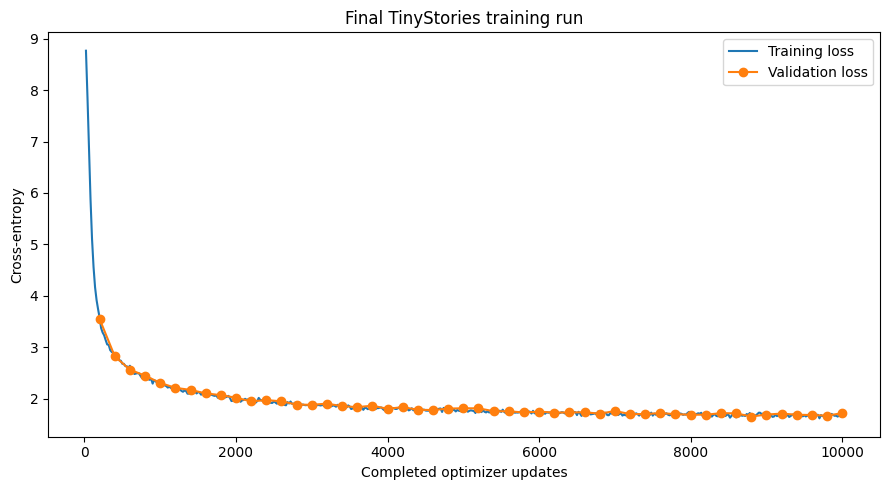

Saved: D:\1 - Personal\Docs\Noor\Gen AI PA1\cs5326-pa1\report_assets\final_loss_curve.png


In [27]:

if not FINAL_METRICS.exists():
    raise FileNotFoundError(FINAL_METRICS)

rows = read_metrics_csv(FINAL_METRICS)

train_steps = [int(row["completed_steps"]) for row in rows]
train_losses = [float(row["train_loss"]) for row in rows]

val_steps = []
val_losses = []
for row in rows:
    if row["validation_loss"]:
        val_steps.append(int(row["completed_steps"]))
        val_losses.append(float(row["validation_loss"]))

plt.figure(figsize=(9, 5))
plt.plot(train_steps, train_losses, label="Training loss")
if val_steps:
    plt.plot(val_steps, val_losses, marker="o", label="Validation loss")
plt.xlabel("Completed optimizer updates")
plt.ylabel("Cross-entropy")
plt.title("Final TinyStories training run")
plt.legend()
plt.tight_layout()

final_loss_figure = ROOT / "report_assets" / "final_loss_curve.png"
plt.savefig(final_loss_figure, dpi=160)
plt.show()
print("Saved:", final_loss_figure)


# Inference and decoding analysis

Use the exact same final trained model used for standardized evaluation. The following cell explores multiple temperature/top-p settings and saves representative generations for your report.


## Cell 25 — Generate samples with temperature and top-p


In [28]:

EOT_TOKEN_ID = tokenizer.token_to_id("<|endoftext|>")
print("EOT token ID:", EOT_TOKEN_ID)

PROMPTS = [
    "Once upon a time",
    "One day, Mia",
]

DECODING_SETTINGS = [
    (0.5, 0.90),
    (0.8, 0.90),
    (1.0, 0.95),
    (1.2, 0.95),
    (1.0, 1.00),
]

sample_blocks = []

for prompt_index, prompt in enumerate(PROMPTS):
    prompt_ids = torch.tensor(
        tokenizer.encode(prompt, add_special_tokens=False).ids,
        dtype=torch.long,
        device=DEVICE,
    )

    for setting_index, (temperature, top_p) in enumerate(DECODING_SETTINGS):
        if DEVICE.type == "cuda":
            sampling_generator = torch.Generator(device="cuda").manual_seed(
                10_000 + prompt_index * 100 + setting_index
            )
        elif DEVICE.type == "cpu":
            sampling_generator = torch.Generator().manual_seed(
                10_000 + prompt_index * 100 + setting_index
            )
        else:
            # Some accelerators do not support device-specific Generator objects.
            sampling_generator = None

        generated_ids = generate(
            final_model,
            prompt_ids,
            max_new_tokens=160,
            context_length=256,
            temperature=temperature,
            top_p=top_p,
            eot_token_id=EOT_TOKEN_ID,
            generator=sampling_generator,
        )

        generated_text = tokenizer.decode(
            generated_ids.detach().cpu().tolist(),
            skip_special_tokens=False,
        )

        block = (
            f"PROMPT: {prompt}\n"
            f"TEMPERATURE: {temperature}\n"
            f"TOP_P: {top_p}\n"
            f"{generated_text}\n"
            + "-" * 80
        )
        sample_blocks.append(block)
        print(block)

samples_path = ROOT / "experiments" / "generated_samples.txt"
samples_path.write_text("\n\n".join(sample_blocks), encoding="utf-8")
print("Saved:", samples_path)


EOT token ID: 0
PROMPT: Once upon a time
TEMPERATURE: 0.5
TOP_P: 0.9
Once upon a time, there was a little girl named Lily. She loved to play outside in the park with her friends. One day, Lily's mom told her they were going on a picnic with her friends. Lily was excited to help her mom.

When they arrived at the park, Lily saw a big slide. She ran to it and climbed up the ladder. She was so happy to slide down the slide. But then, she saw a boy who was being mean to Lily. He was not nice. Lily felt sad and wanted to help him.

Lily remembered her mom's words and felt bad. She realized that it's important to be kind and help others. She decided to share her toys with the boy and they became friends. They played together and had fun. Lily learned that it
--------------------------------------------------------------------------------
PROMPT: Once upon a time
TEMPERATURE: 0.8
TOP_P: 0.9
Once upon a time, there was a little girl named Lily. She loved to play with her toys and have fun. One

# Export the LMS model artifact

`final_model.pt` must be a plain model `state_dict`, with every floating tensor on CPU in FP16. It must contain exactly **19,272,192 tensor values**.


## Cell 26 — Export and validate `final_model.pt`


In [29]:

final_state = export_final_model(final_model, ROOT / "final_model.pt")

num_values = sum(tensor.numel() for tensor in final_state.values())
print("Tensor values:", f"{num_values:,}")
assert num_values == 19_272_192

for name, tensor in final_state.items():
    assert tensor.device.type == "cpu", f"{name} is not on CPU"
    if tensor.is_floating_point():
        assert tensor.dtype == torch.float16, f"{name} is not float16"
        assert torch.isfinite(tensor).all(), f"{name} contains non-finite values"

print("final_model.pt passed the artifact checks.")


Tensor values: 19,272,192
final_model.pt passed the artifact checks.


# REPORT.md checklist

Before packaging, complete the supplied `REPORT.md` using the **actual evidence produced above**.

Your report should cover:

1. controlled hyperparameter exploration and why it informed your final settings;
2. the final 10,000-update training run, including useful plots/numerical summaries;
3. final standardized validation cross-entropy and perplexity;
4. temperature and top-p behavior, with representative generated examples;
5. figures stored under `report_assets/`.

Do not fabricate results. The final model, final evaluation, and generated samples in the report must all correspond to the same final trained model.


## Cell 27 — Print the key values to paste/analyze in the report


In [30]:

print("FINAL ARCHITECTURE")
print(json.dumps(FINAL_ARCH, indent=2))
print()

print("FINAL TRAINING CONFIG")
for key, value in FINAL_CONFIG.__dict__.items():
    print(f"{key}: {value}")
print()

print("STANDARDIZED FINAL EVALUATION")
print(f"cross-entropy: {final_validation_ce:.6f} nats/token")
print(f"perplexity: {final_perplexity:.6f}")
print()

print("REPORT ASSETS")
for path in sorted((ROOT / "report_assets").glob("*")):
    if path.is_file():
        print(path.relative_to(ROOT))

print()
print("Generated samples:", (ROOT / "experiments" / "generated_samples.txt"))


FINAL ARCHITECTURE
{
  "vocab_size": 8192,
  "context_length": 256,
  "d_model": 512,
  "num_layers": 4,
  "n_q_heads": 16,
  "n_kv_heads": 4,
  "d_ff": 1344,
  "rope_theta": 10000.0,
  "norm_eps": 1e-05
}

FINAL TRAINING CONFIG
batch_size: 16
sequence_length: 256
gradient_accumulation_steps: 16
num_steps: 10000
learning_rate_max: 0.0003
learning_rate_min: 3e-05
warmup_steps: 200
cosine_steps: 9999
betas: (0.9, 0.95)
adam_eps: 1e-08
weight_decay: 0.1
max_grad_norm: 1.0
eval_interval: 200
log_interval: 20
checkpoint_interval: 500
num_validation_batches: 20
train_seed: 12345
val_seed: 54321

STANDARDIZED FINAL EVALUATION
cross-entropy: 1.683344 nats/token
perplexity: 5.383529

REPORT ASSETS
report_assets\.gitkeep
report_assets\final_loss_curve.png

Generated samples: D:\1 - Personal\Docs\Noor\Gen AI PA1\cs5326-pa1\experiments\generated_samples.txt


# Final verification and packaging

Run the complete public suite again. Then run `make_submission.sh`.

On Windows, the packaging script requires a Bash environment such as **Git Bash** or **WSL**. If `bash` is not available in the notebook kernel environment, run the command manually from Git Bash in the repository root.


## Cell 28 — Final public-test run


In [31]:

result = subprocess.run(["uv", "run", "pytest", "-q"], cwd=ROOT, text=True)
if result.returncode != 0:
    raise RuntimeError("Public tests failed. Do not submit yet.")
print("All public tests passed.")


All public tests passed.


## Cell 29 — Build `submission.zip`


In [34]:

RUN_PACKAGING = False

if RUN_PACKAGING:
    if shutil.which("bash") is None:
        print(
            "Bash is not available here. Open Git Bash or WSL in the repository root and run:\n"
            "bash make_submission.sh"
        )
    else:
        result = subprocess.run(
            ["bash", "make_submission.sh"],
            cwd=ROOT,
            text=True,
        )
        if result.returncode != 0:
            raise RuntimeError("make_submission.sh failed.")
        print("Created:", ROOT / "submission.zip")
        print("Rename it to <roll_number_pa1>.zip before LMS upload.")
else:
    print("Skipped. Complete REPORT.md first, then set RUN_PACKAGING = True.")


Skipped. Complete REPORT.md first, then set RUN_PACKAGING = True.


## Final manual steps

After all notebook sections are complete:

1. Read `REPORT.md` yourself and ensure it accurately analyzes your real experiments.
2. Confirm `report_assets/` contains every figure referenced by the report.
3. Confirm `final_model.pt` came from the same final model used for evaluation and generation.
4. Run the full tests one final time.
5. Create `submission.zip`.
6. Rename it to `<roll_number_pa1>.zip`.
7. Upload that ZIP to LMS.
